# Business Understanding

## 🧠 Project Domain <br>

Domain:  Psychology & Personality Profiling
Sub-Domain:  Digital Personality Assessment & AI-Powered Self-Discovery<br>
<br>

Sistem prediksi MBTI ini merupakan bagian dari solusi teknologi dalam bidang psikologi kepribadian, khususnya pada asesmen digital berbasis data. Sistem ini dirancang untuk mempermudah pengguna mengenali kecenderungan kepribadian mereka hanya dengan memasukkan beberapa skor dimensi MBTI seperti introversi, sensing, thinking, dan judging.

Dengan memanfaatkan model machine learning (Artificial Neural Network) yang telah dikonversi ke TensorFlow Lite, sistem ini mampu memberikan prediksi kepribadian secara cepat, ringan, dan efisien melalui aplikasi berbasis web Streamlit. Tidak hanya itu, hasil prediksi juga dilengkapi dengan deskripsi karakter, tokoh terkenal, dan tipe pasangan ideal sesuai hasil MBTI pengguna.

## ❗Problem Statements <br>


1. Tes MBTI Konvensional Membosankan & Panjang
  *   Tes MBTI biasanya terdiri dari puluhan pertanyaan dan memakan waktu. Banyak pengguna merasa bosan atau tidak jujur dalam menjawab.
2. Kurangnya Interpretasi Sederhana
  *  Setelah mendapatkan hasil MBTI, sebagian besar orang kesulitan memahami arti kepribadiannya, apalagi tidak disertai konteks.
  
3. Tidak Ada Koneksi Emosional dengan Hasil
  *   Hasil MBTI tanpa penjelasan atau contoh nyata terasa kering. Pengguna butuh referensi nyata seperti tokoh terkenal atau pasangan ideal.

## 🎯 Goals

Membangun sistem berbasis AI yang bisa memprediksi tipe kepribadian MBTI seseorang berdasarkan:

*  Introversion Score
*  Sensing Score
*  Thinking Score
*  Judging Score
*  Usia

Hasil prediksi dilengkapi dengan deskripsi tipe, tokoh terkenal yang memiliki tipe yang sama dan tipe pasangan yang cocok.

## ✅ Solution Statements

*   Model Machine Learning
Menggunakan Artificial Neural Network (ANN) dan dikonversi ke TensorFlow Lite agar bisa dijalankan secara efisien.
*   Antarmuka Web Interaktif (Streamlit)
Dibuat tampilan yang user-friendly agar pengguna bisa memasukkan nilai-nilai kepribadian dan langsung melihat tipe MBTI-nya.
*   Hasil prediksi dilengkapi dengan penjelasan kepribadian, tokoh inspiratif yang relevan, dan tipe pasangan ideal — membuat pengalaman lebih bermakna.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asteriavira","key":"8fe8cbff5c4dd0ffbb058a72ba60344d"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d stealthtechnologies/predict-people-personality-types

Dataset URL: https://www.kaggle.com/datasets/stealthtechnologies/predict-people-personality-types
License(s): MIT


In [4]:
!mkdir predict-people-personality-types-dataset
!unzip predict-people-personality-types.zip -d predict-people-personality-types-dataset
!ls predict-people-personality-types-dataset

Archive:  predict-people-personality-types.zip
  inflating: predict-people-personality-types-dataset/data.csv  
data.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping

## Exploratory Data Analysis

In [6]:
df = pd.read_csv('predict-people-personality-types-dataset/data.csv')

In [7]:
df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43744 entries, 0 to 43743
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 43744 non-null  float64
 1   Gender              43744 non-null  object 
 2   Education           43744 non-null  int64  
 3   Introversion Score  43744 non-null  float64
 4   Sensing Score       43744 non-null  float64
 5   Thinking Score      43744 non-null  float64
 6   Judging Score       43744 non-null  float64
 7   Interest            43744 non-null  object 
 8   Personality         43744 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 3.0+ MB


In [9]:
df = df.drop(columns=['Interest','Education','Gender'])

In [10]:
df.head()

,Age,Introversion Score,Sensing Score,Thinking Score,Judging Score,Personality
0,21.0,5.89208,2.144395,7.32363,5.462224,ENTP
1,24.0,2.48366,3.206188,8.06876,3.765012,INTP
2,26.0,7.02910,6.469302,4.16472,5.454442,ESFP
3,30.0,5.46525,4.179244,2.82487,5.080477,ENFJ
4,31.0,3.59804,6.189259,5.31347,3.677984,ISFP


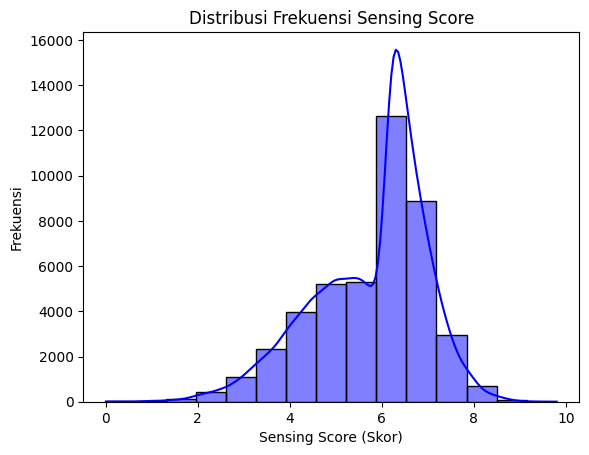

In [11]:
#  Distribusi frekuensi Sensing Score
sns.histplot(df['Sensing Score'],
             kde=True,
             color='blue',
             bins=15)
plt.title("Distribusi Frekuensi Sensing Score")
plt.xlabel("Sensing Score (Skor)")
plt.ylabel("Frekuensi")
plt.show()

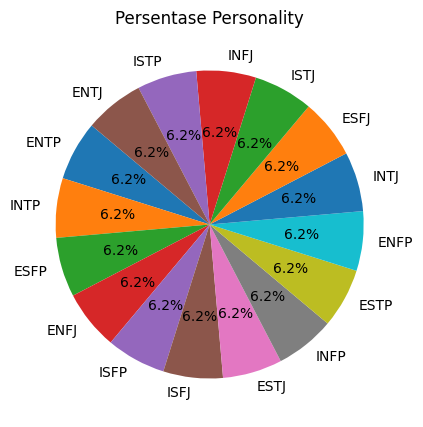

In [12]:
# pie chart
plt.figure(figsize=(5, 5))
df['Personality'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Persentase Personality")
plt.ylabel("")
plt.show()

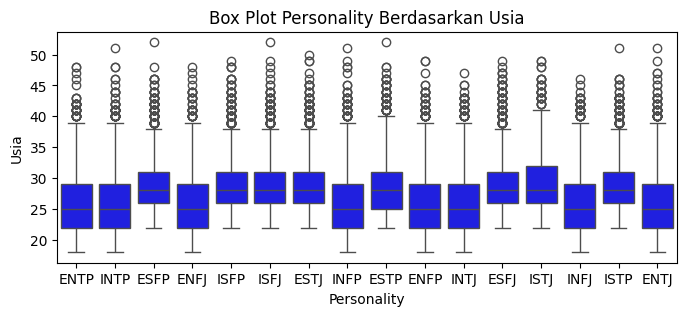

In [13]:
# box plot of age by personality
plt.figure(figsize=(8, 3))
sns.boxplot(x='Personality', y='Age', color='blue', data=df)
plt.title("Box Plot Personality Berdasarkan Usia")
plt.xlabel("Personality")
plt.ylabel("Usia")
plt.show()

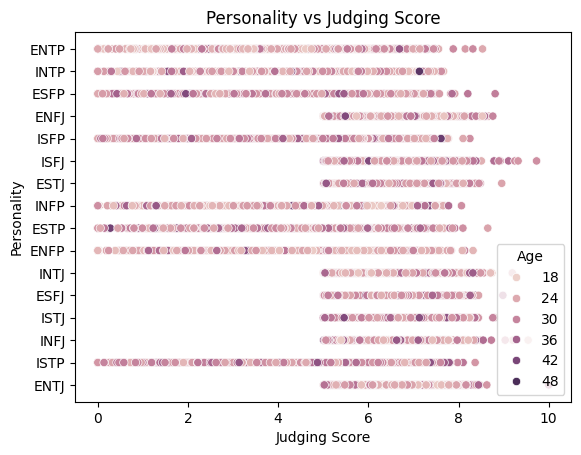

In [14]:
# 4. Scatter Plot : Usia berdasarkan jumlah klaim
sns.scatterplot(x='Judging Score', y='Personality', hue='Age', data=df)
plt.title('Personality vs Judging Score')
plt.show()

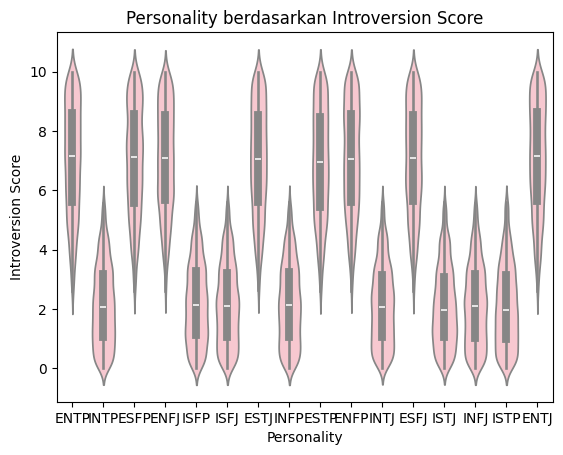

In [15]:
sns.violinplot(x='Personality', y='Introversion Score', color='pink', data=df)
plt.title('Personality berdasarkan Introversion Score')
plt.show()

# Data Preparation

In [16]:
# pisahkan fitur dan target
X = df.drop(columns=["Personality"])
y = df["Personality"]

In [17]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [18]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [29]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,632 (45.44 KB)

 Trainable params: 11,632 (45.44 KB)

 Non-trainable params: 0 (0.00 B)

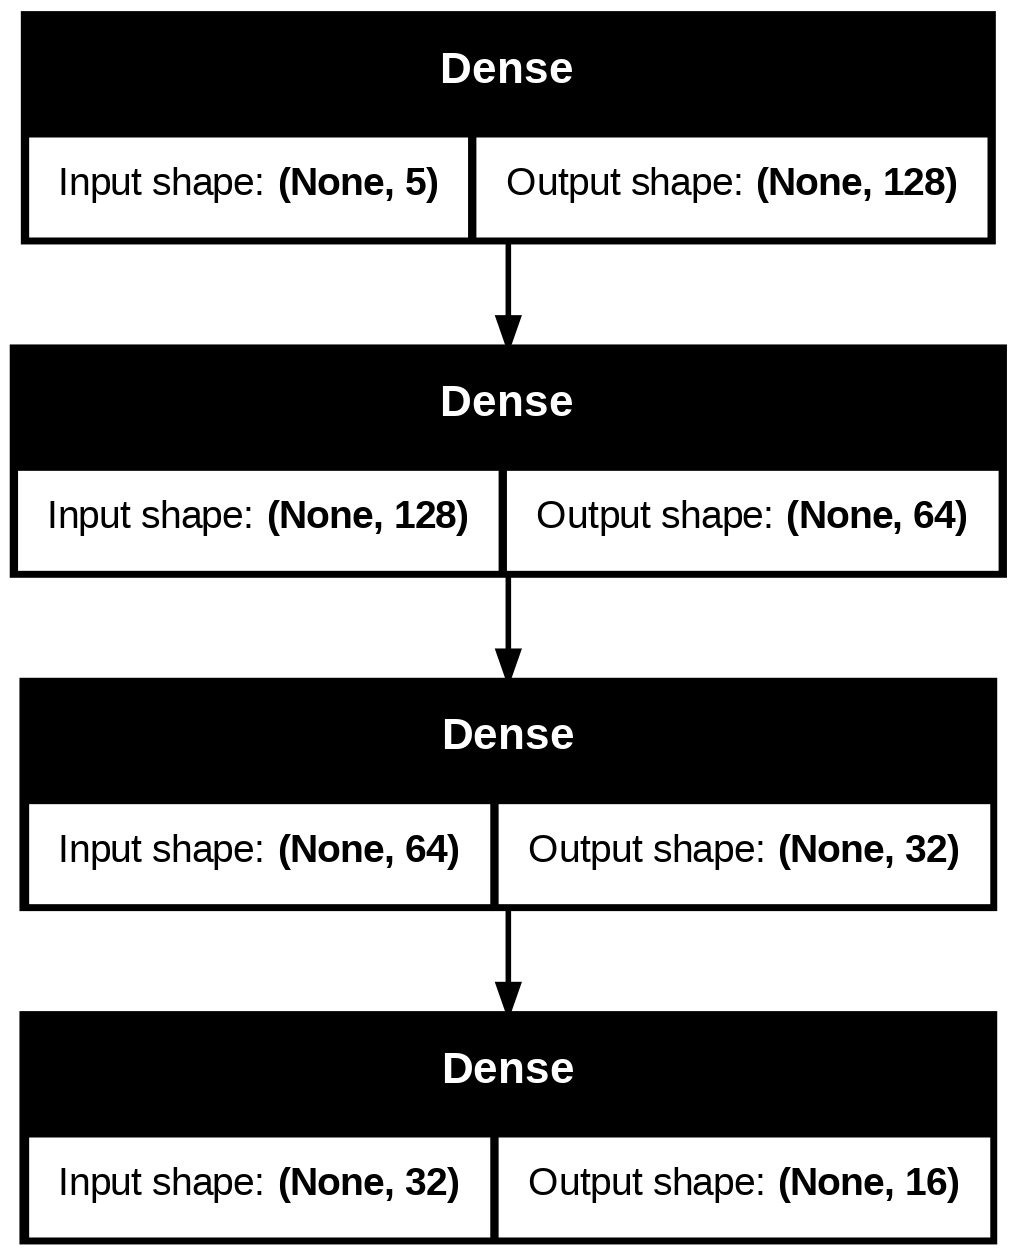

In [32]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [33]:
# Early stopping untuk hentikan training saat model mulai overfit
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7271 - loss: 0.6684 - val_accuracy: 0.7276 - val_loss: 0.6790
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7270 - loss: 0.6707 - val_accuracy: 0.7208 - val_loss: 0.6755
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7238 - loss: 0.6711 - val_accuracy: 0.7308 - val_loss: 0.7002
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7280 - loss: 0.6674 - val_accuracy: 0.7183 - val_loss: 0.6956
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7290 - loss: 0.6617 - val_accuracy: 0.7221 - val_loss: 0.6957
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7281 - loss: 0.6571 - val_accuracy: 0.7272 - val_loss: 0.6701
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7300 - loss: 0.6616 - val_accuracy: 0.7313 - val_loss: 0.6798
Epoch 8/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7308 - loss: 0.6627 - 


# Evaluation

In [37]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7256 - loss: 0.6797
Akurasi Model: 0.7323
Loss Model: 0.6750


In [38]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

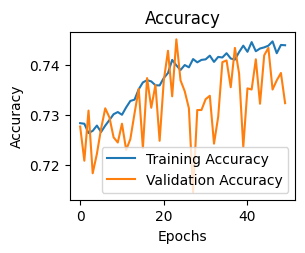

In [39]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

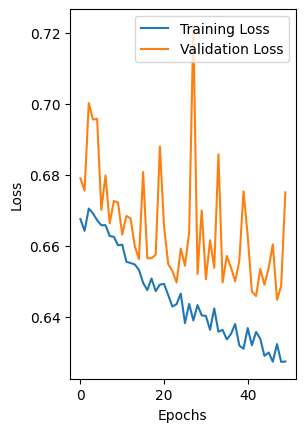

In [40]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


# Deployment

## Model Simulation

In [41]:
sample_input = np.array([[21, 10 ,5, 8, 1]])
sample_input_df = pd.DataFrame(sample_input)

In [42]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [43]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Tipe MBTI mu adalah: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Tipe MBTI mu adalah: ENTP


## Save Model

In [44]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('predict_type_personality.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpf23g3lri'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  139101706130192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101706129232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697311184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697316176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697314064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697316944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139101697318288: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [45]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']